In [52]:
import pandas as pd
import numpy as np  
import random
import matplotlib.pyplot as plt

df = pd.read_csv("../processed_ml_dataset.csv")
df.head()

,"On a scale of 1–10, how intense is the emotion conveyed by the artwork?",This art piece makes me feel sombre.,This art piece makes me feel content.,This art piece makes me feel calm.,This art piece makes me feel uneasy.,How many prominent colours do you notice in this painting?,How many objects caught your eye in the painting?,How much (in Canadian dollars) would you be willing to pay for this painting?,Painting_Target,room_Living_room,...,sound_violin,sound_peaceful,sound_upbeat,sound_light,sound_classical,sound_happy,sound_wind,sound_sad,sound_gentle,sound_low
0,7.0,3.0,4.0,4.0,2.0,5.0,3.0,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5.0,4.0,3.0,2.0,1.0,2.0,4.0,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7.0,4.0,1.0,1.0,4.0,4.0,3.0,5.0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,7.0,4.0,1.0,2.0,4.0,10.0,7.0,0.0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,7.0,3.0,4.0,5.0,3.0,4.0,6.0,300.0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [53]:
X = df.drop(columns=["Painting_Target"]).to_numpy()
y = df["Painting_Target"].astype(int).to_numpy()
y= np.eye(3)[y]

print(X.shape)
print(y.shape)

(1686, 67)
(1686, 3)


In [54]:
np.random.seed(0)

indices = np.random.permutation(X.shape[0])
X = X[indices]
y = y[indices]

split_idx = int(0.8 * X.shape[0])

X_train = X[:split_idx]
y_train = y[:split_idx]

X_val = X[split_idx:]
y_val = y[split_idx:]

mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

std[std == 0] = 1

X_train = (X_train - mean) / std
X_val = (X_val - mean) / std

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)


(1348, 67) (1348, 3)
(338, 67) (338, 3)


In [55]:
def softmax(z):
    """
    Compute the softmax of vector z, or row-wise for a matrix z.
    For numerical stability, subtract the maximum logit value from each
    row prior to exponentiation (see above).

    Parameters:
        `z` - a numpy array of shape (K,) or (N, K)

    Returns: a numpy array with the same shape as `z`, with the softmax
        activation applied to each row of `z`
    """
    if z.ndim == 1:
        m = max(z)
        return np.exp(z - m) / np.sum(np.exp(z - m))
    else:
      m = np.max(z, axis=1, keepdims=True)
      numerator = np.exp(z - m)
      denominator = np.sum(np.exp(z - m), axis = 1, keepdims=True)
      return numerator / denominator

In [56]:
class MLPModel(object):
    def __init__(self, num_features=67, num_hidden=100, num_classes=3):
        """
        Initialize the weights and biases of this two-layer MLP.
        """
        # information about the model architecture
        self.num_features = num_features
        self.num_hidden = num_hidden
        self.num_classes = num_classes

        # weights and biases for the first layer of the MLP
        self.W1 = np.zeros([num_hidden, num_features])
        self.b1 = np.zeros([num_hidden])

        # weights and biases for the second layer of the MLP
        self.W2 = np.zeros([num_classes, num_hidden])
        self.b2 = np.zeros([num_classes])

        # initialize the weights and biases
        self.initializeParams()

        # set all values of intermediate variables (to be used in the
        # forward/backward passes) to None
        self.cleanup()

    def initializeParams(self):
        """
        Initialize the weights and biases of this two-layer MLP to be random.
        This random initialization is necessary to break the symmetry in the
        gradient descent update for our hidden weights and biases. If all our
        weights were initialized to the same value, then their gradients will
        all be the same!
        """
        self.W1 = np.random.normal(0, 2/self.num_features, self.W1.shape)
        self.b1 = np.random.normal(0, 2/self.num_features, self.b1.shape)
        self.W2 = np.random.normal(0, 2/self.num_hidden, self.W2.shape)
        self.b2 = np.random.normal(0, 2/self.num_hidden, self.b2.shape)

    def forward(self, X):
        """
        Compute the forward pass to produce prediction for inputs.

        Parameters:
            `X` - A numpy array of shape (N, self.num_features)

        Returns: A numpy array of predictions of shape (N, self.num_classes)
        """
        return do_forward_pass(self, X) # To be implemented below

    def backward(self, ts):
        """
        Compute the backward pass, given the ground-truth, one-hot targets.

        You may assume that the `forward()` method has been called for the
        corresponding input `X`, so that the quantities computed in the
        `forward()` method is accessible.

        Parameters:
            `ts` - A numpy array of shape (N, self.num_classes)
        """
        return do_backward_pass(self, ts) # To be implemented below

    def loss(self, ts):
        """
        Compute the average cross-entropy loss, given the ground-truth, one-hot targets.

        You may assume that the `forward()` method has been called for the
        corresponding input `X`, so that the quantities computed in the
        `forward()` method is accessible.

        Parameters:
            `ts` - A numpy array of shape (N, self.num_classes)
        """
        y_clipped = np.clip(self.y, 1e-12, 1.0)
        return np.sum(-ts * np.log(y_clipped)) / ts.shape[0]

    def update(self, alpha):
        """
        Compute the gradient descent update for the parameters of this model.

        Parameters:
            `alpha` - A number representing the learning rate
        """
        self.W1 = self.W1 - alpha * self.W1_bar
        self.b1 = self.b1 - alpha * self.b1_bar
        self.W2 = self.W2 - alpha * self.W2_bar
        self.b2 = self.b2 - alpha * self.b2_bar

    def cleanup(self):
        """
        Erase the values of the variables that we use in our computation.
        """
        # To be filled in during the forward pass
        self.N = None # Number of data points in the batch
        self.X = None # The input matrix
        self.m = None # Pre-activation value of the hidden state, should have shape
        self.h = None # Post-RELU value of the hidden state
        self.z = None # The logit scores (pre-activation output values)
        self.y = None # Class probabilities (post-activation)
        # To be filled in during the backward pass
        self.z_bar = None # The error signal for self.z2
        self.W2_bar = None # The error signal for self.W2
        self.b2_bar = None # The error signal for self.b2
        self.h_bar = None  # The error signal for self.h
        self.m_bar = None # The error signal for self.z1
        self.W1_bar = None # The error signal for self.W1
        self.b1_bar = None # The error signal for self.b1

In [57]:
def do_forward_pass(model, X):
    """
    Compute the forward pass to produce prediction for inputs.

    This function also keeps some of the intermediate values in
    the neural network computation, to make computing gradients easier.

    For the ReLU activation, you may find the function `np.maximum` helpful

    Parameters:
        `model` - An instance of the class MLPModel
        `X` - A numpy array of shape (N, model.num_features)

    Returns: A numpy array of predictions of shape (N, model.num_classes)
    """
    model.N = X.shape[0]
    model.X = X
    model.m = X @ model.W1.T + model.b1 # TODO - the hidden state value (pre-activation)
    model.h = np.maximum(0, model.m) # TODO - the hidden state value (post ReLU activation)
    model.z = model.h @ model.W2.T + model.b2 # TODO - the logit scores (pre-activation)
    model.y = softmax(model.z) # TODO - the class probabilities (post-activation)
    return model.y


In [58]:
def do_backward_pass(model, ts):
    """
    Compute the backward pass, given the ground-truth, one-hot targets.

    You may assume that `model.forward()` has been called for the
    corresponding input `X`, so that the quantities computed in the
    `forward()` method is accessible.

    The member variables you store here will be used in the `update()`
    method. Check that the shapes match what you wrote in Part 2.

    Parameters:
        `model` - An instance of the class MLPModel
        `ts` - A numpy array of shape (N, model.num_classes)
    """
    model.z_bar = (model.y - ts) / model.N
    model.W2_bar = model.z_bar.T @ model.h
    model.b2_bar = np.sum(model.z_bar, axis=0)
    model.h_bar = model.z_bar @ model.W2
    model.m_bar = model.h_bar * (model.m > 0)
    model.W1_bar = model.m_bar.T @ model.X
    model.b1_bar = np.sum(model.m_bar, axis=0)


In [59]:
model = MLPModel(num_features=67, num_hidden=100, num_classes=3)

num_epochs = 200
learning_rate = 0.01

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.forward(X_train)
    train_loss = model.loss(y_train)
    model.backward(y_train)
    model.update(learning_rate)

    model.forward(X_val)
    val_loss = model.loss(y_val)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")


Epoch 0: train_loss=1.0966, val_loss=1.0981
Epoch 10: train_loss=1.0907, val_loss=1.0922
Epoch 20: train_loss=1.0848, val_loss=1.0863
Epoch 30: train_loss=1.0788, val_loss=1.0803
Epoch 40: train_loss=1.0727, val_loss=1.0740
Epoch 50: train_loss=1.0664, val_loss=1.0675
Epoch 60: train_loss=1.0598, val_loss=1.0607
Epoch 70: train_loss=1.0529, val_loss=1.0535
Epoch 80: train_loss=1.0456, val_loss=1.0458
Epoch 90: train_loss=1.0378, val_loss=1.0376
Epoch 100: train_loss=1.0295, val_loss=1.0287
Epoch 110: train_loss=1.0205, val_loss=1.0192
Epoch 120: train_loss=1.0110, val_loss=1.0090
Epoch 130: train_loss=1.0007, val_loss=0.9980
Epoch 140: train_loss=0.9897, val_loss=0.9862
Epoch 150: train_loss=0.9779, val_loss=0.9735
Epoch 160: train_loss=0.9652, val_loss=0.9599
Epoch 170: train_loss=0.9518, val_loss=0.9455
Epoch 180: train_loss=0.9376, val_loss=0.9302
Epoch 190: train_loss=0.9226, val_loss=0.9141


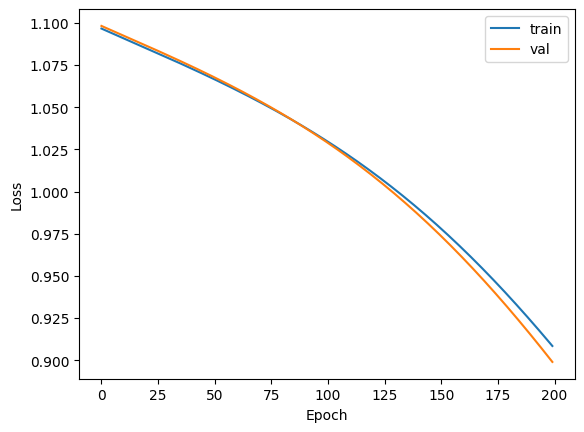

In [60]:
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [61]:
train_probs = model.forward(X_train)
train_preds = np.argmax(train_probs, axis=1)
train_true = np.argmax(y_train, axis=1)
train_accuracy = np.mean(train_preds == train_true)

val_probs = model.forward(X_val)
val_preds = np.argmax(val_probs, axis=1)
val_true = np.argmax(y_val, axis=1)
val_accuracy = np.mean(val_preds == val_true)

print(f"Training accuracy: {train_accuracy * 100:.2f}%")
print(f"Validation accuracy: {val_accuracy * 100:.2f}%")


Training accuracy: 81.68%
Validation accuracy: 80.47%
